In [2]:
import tensorflow as tf
import keras
import numpy as np
import pandas as pd
from customlayer import MyLayerNorm
from functions import get_keras_vals, get_custom_vals, comp_layer
import matplotlib.pyplot as plt

In [3]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

In [4]:
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [5]:
X_train = X_train / 255.0
X_valid = X_valid / 255.0
X_test = X_test / 255.0

In [7]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [17]:
X_valid.shape

(5000, 28, 28)

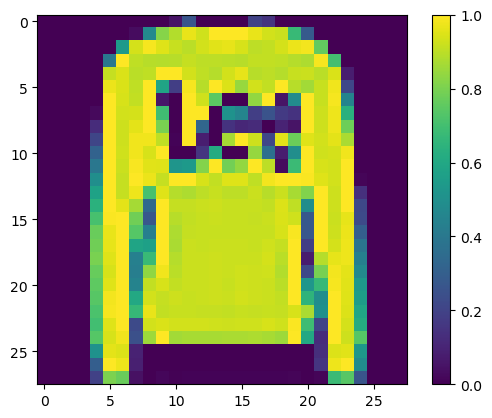

In [18]:
plt.figure()
plt.imshow(X_test[1])
plt.colorbar()
plt.grid(False)
plt.show()

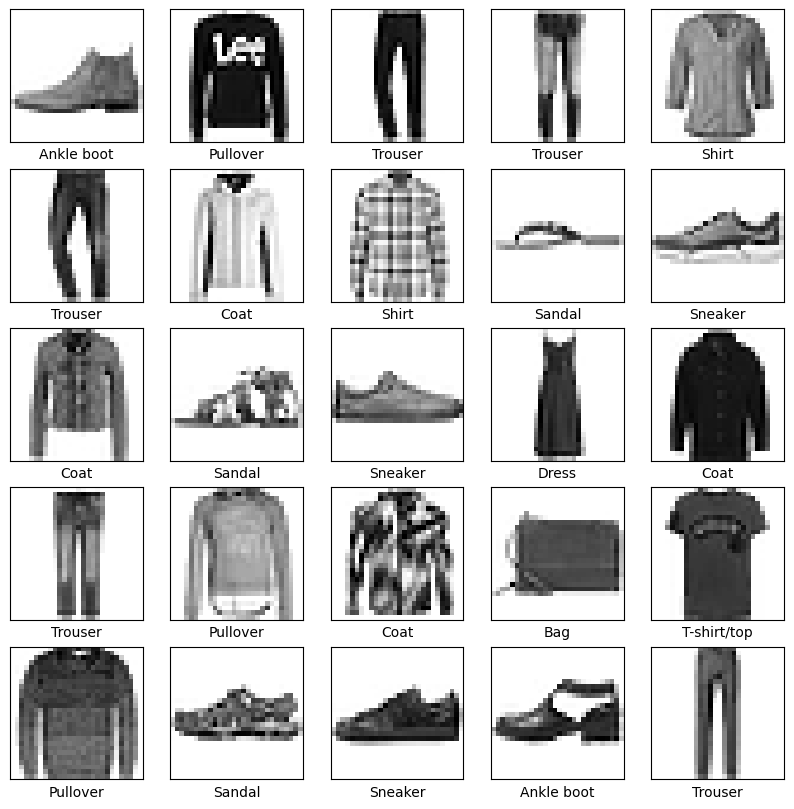

In [8]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_test[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[y_test[i]])
plt.show()

In [10]:
mnist_df = comp_layer(tensor=X_valid, batch_size=32, axis=[1, 2])

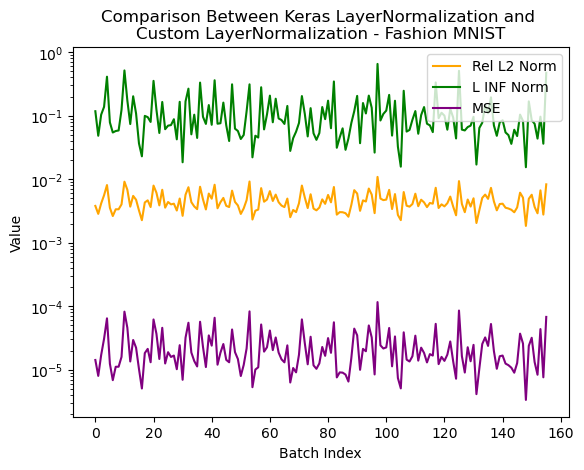

In [12]:
plt.plot(mnist_df[0], label="Rel L2 Norm", color="orange")
plt.plot(mnist_df[1], label="L INF Norm", color="green")
plt.plot(mnist_df[2], label="MSE", color="purple")
plt.title("Comparison Between Keras LayerNormalization and \nCustom LayerNormalization - Fashion MNIST")
plt.xlabel("Batch Index")
plt.ylabel("Value")
plt.yscale('log')
plt.legend()
plt.show()